# Modelos y Evaluación con el DataFrame Procesado
## 1. Inicialización
Tras haber limpiado y guardado anteriormente el dataset con la imputación y demás la cargamos aquí para poder relaizar la evaluación de nuestro datast y tratar de realizar diversas predicciones de paises.

Para ello antes de entrenar ningún modelo, a parte de lo anterior, añadiremos una columna más que rellenearemos con la información de en qué cluster cae cada pais tras haberlo comprobado con kameans después de la imputación definitiva hecha en `01_Limpieza_y_Tratamiento`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# 1. Cargar los datasets exportados
X_df = pd.read_csv('../dataset/X_vulnerabilidad_info.csv')
y = pd.read_csv('../dataset/y_vulnerabilidad.csv').squeeze() # Lo convertimos en Serie

# 2. Separar metadatos (identificadores) de las variables predictoras puras
id_cols = ['Country Name', 'Country Code', 'Time']
X_features = X_df.drop(columns=id_cols)
metadata = X_df[id_cols].copy()

# 3. Estandarizar las variables predictoras (requisito indispensable para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 4. Aplicar Clustering de Países (DBSCAN)
# Probemos inicialmente con 4 clústeres (por ejemplo: Bajo, Medio-Bajo, Medio-Alto, Alto desarrollo/vulnerabilidad)
dbscan = DBSCAN(eps=0.5, min_samples=5)
metadata['Cluster_Pais'] = dbscan.fit_predict(X_scaled)

# 5. Integrar el Clúster como una nueva característica (Feature) en nuestra matriz X
# Convertimos el clúster a variable numérica para que el modelo predictivo pueda leerlo
X_features['Cluster_Pais'] = metadata['Cluster_Pais']

print("¡Clustering de países aplicado con éxito!")
print(metadata['Cluster_Pais'].value_counts())

¡Clustering de países aplicado con éxito!
Cluster_Pais
-1    6821
 5      12
 4      10
 2       6
 0       5
 1       5
 3       5
Name: count, dtype: int64


## 2.RandomForest

Como modelo base para inicializar esta evaluación usaremos un RandomForest de modo que se generaran una serie de árboles de decisión los cuales se irán perfeccionando en cada generación hasta

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Definir matriz X (con el nuevo clúster incluido) e y (target)
X_final = X_features.copy()

# 2. Separación de datos: 80% para entrenamiento y 20% para test
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"Dimensiones de entrenamiento (Train): {X_train.shape}")
print(f"Dimensiones de prueba (Test): {X_test.shape}")

# 3. Entrenar el modelo base (Random Forest Regressor)
modelo_base = RandomForestRegressor(random_state=42, n_estimators=100)
modelo_base.fit(X_train, y_train)

# 4. Evaluación inicial rápida
y_pred = modelo_base.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Resultados del Modelo Base ---")
print(f"R² Score (Coeficiente de Determinación): {r2:.4f}")
print(f"RMSE (Error Cuadrático Medio): {rmse:.4f}")

Dimensiones de entrenamiento (Train): (5491, 55)
Dimensiones de prueba (Test): (1373, 55)

--- Resultados del Modelo Base ---
R² Score (Coeficiente de Determinación): 0.9557
RMSE (Error Cuadrático Medio): 2.8798


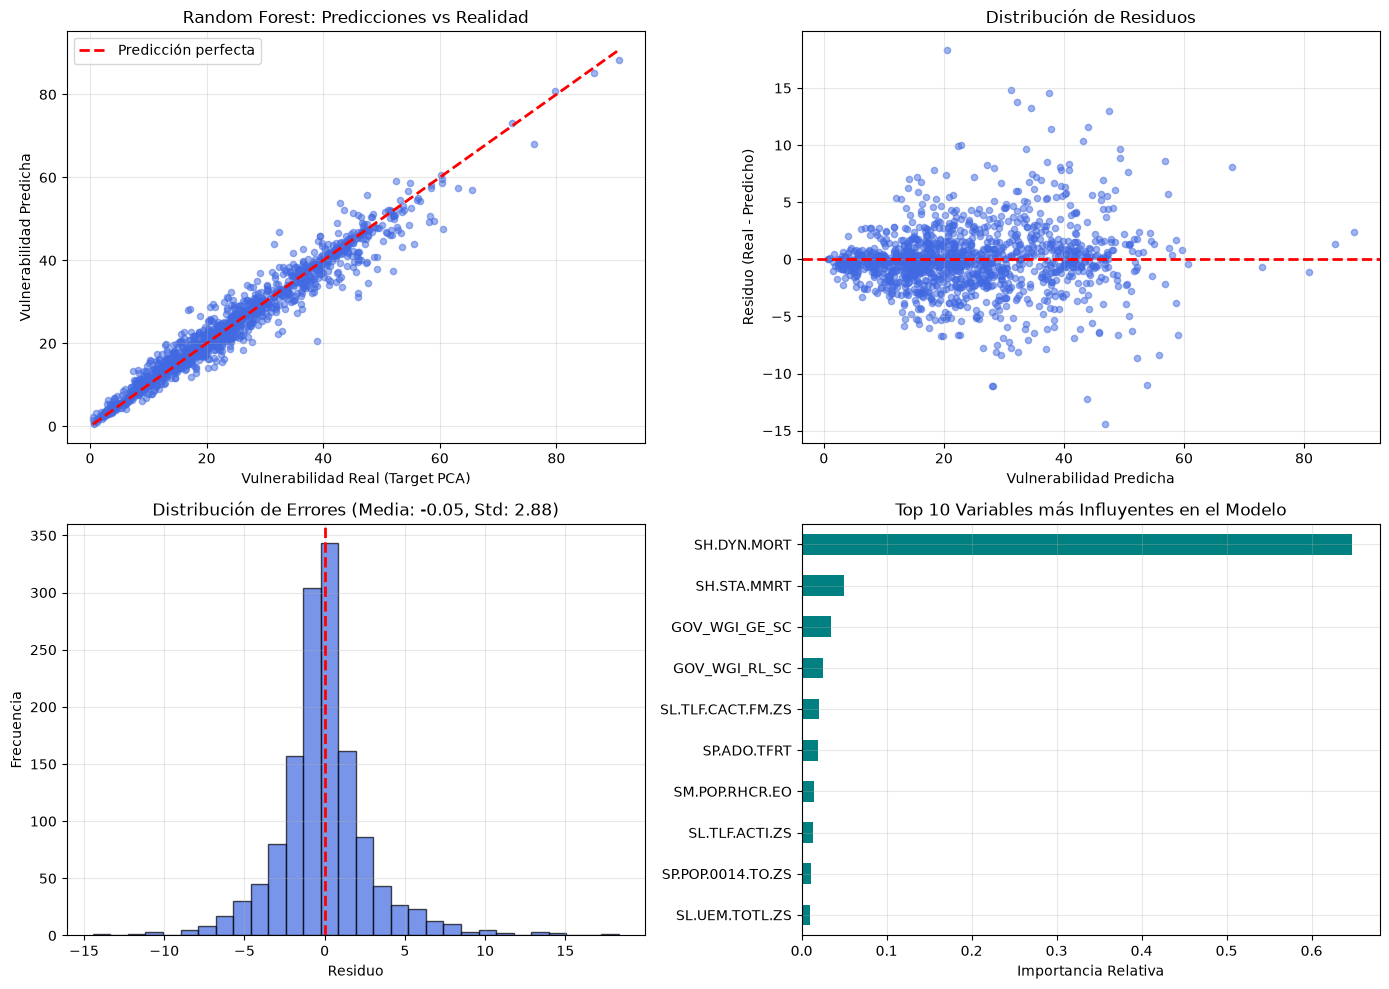

MÉTRICAS DE RENDIMIENTO - RANDOM FOREST
Residuo promedio: -0.0532
Desv. estándar de residuos: 2.8793
R² Score: 0.9557
RMSE: 2.8798
Error porcentual absoluto: 10.38%


In [3]:
# ============ VISUALIZACIÓN: RANDOM FOREST (VULNERABILIDAD) ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 🔵 GRÁFICA 1 (arriba-izquierda): Predicciones vs Reales
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.5, s=20, color='royalblue')
min_val = np.minimum(y_test.min(), y_pred.min())
max_val = np.maximum(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('Vulnerabilidad Real (Target PCA)')
ax1.set_ylabel('Vulnerabilidad Predicha')
ax1.set_title('Random Forest: Predicciones vs Realidad')
ax1.legend()
ax1.grid(alpha=0.3)

# 🔵 GRÁFICA 2 (arriba-derecha): Distribución de Residuos
ax2 = axes[0, 1]
residuos = y_test.to_numpy().flatten() - y_pred.flatten()
ax2.scatter(y_pred, residuos, alpha=0.5, s=20, color='royalblue')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Vulnerabilidad Predicha')
ax2.set_ylabel('Residuo (Real - Predicho)')
ax2.set_title('Distribución de Residuos')
ax2.grid(alpha=0.3)

# 🔵 GRÁFICA 3 (abajo-izquierda): Histograma de Residuos
ax3 = axes[1, 0]
ax3.hist(residuos, bins=30, edgecolor='black', alpha=0.7, color='royalblue')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuo')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución de Errores (Media: {residuos.mean():.2f}, Std: {residuos.std():.2f})')
ax3.grid(alpha=0.3)

# 🔵 GRÁFICA 4 (abajo-derecha): Importancia de Variables (Feature Importance)
# Esta sustituye al error porcentual ya que el Target es un índice y aporta un valor analítico brutal para el TFG
ax4 = axes[1, 1]
importancias = pd.Series(modelo_base.feature_importances_, index=X_final.columns)
importancias.nlargest(10).sort_values().plot(kind='barh', ax=ax4, color='teal')
ax4.set_xlabel('Importancia Relativa')
ax4.set_title('Top 10 Variables más Influyentes en el Modelo')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# IMPRESIÓN DE ESTADÍSTICAS FINALES
# ====================================================================

error_pct_rf = np.abs((y_test.to_numpy().flatten() - y_pred.flatten()) / y_test.to_numpy().flatten() * 100)# Calculamos el error porcentual absoluto

print("====================================================")
print("MÉTRICAS DE RENDIMIENTO - RANDOM FOREST")
print("====================================================")
print(f'Residuo promedio: {residuos.mean():.4f}')
print(f'Desv. estándar de residuos: {residuos.std():.4f}')
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'Error porcentual absoluto: {error_pct_rf.mean():.2f}%')
print("====================================================")

## Primeros resultados
Con esta primera versión de un RandomForest podemos ver un buen resultado ya con una parte explicada de un $95'63$% lo cual ya está genial. Sin embargo trataremos de seguirlo pereccionando ya sea probando otros modelos como el XGBoost y tratando de optimizar los hiperparámetros a ver hasta donde llegamos haciendo uso por ejemplo de `optuna` .

In [4]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# ==============================================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA Y VALIDACIÓN CRUZADA
# ==============================================================================

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 100, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    # max_features: 'sqrt' o 'log2' evitan el sobreajuste al limitar las variables por árbol
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # 2. Instanciar el modelo con los parámetros sugeridos en esta iteración
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1 # Usar todos los núcleos para acelerar el proceso
    )

    # 3. Validación Cruzada (5 particiones)
    # Importante: Usamos los datos completos de entrenamiento (X_train, y_train)
    # y optimizamos buscando el mayor R²
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
    
    # Retornamos la media del R² en los 5 folds
    return scores.mean()

# 4. Crear el estudio y ejecutar la optimización
print("Iniciando la optimización con Optuna...")
study = optuna.create_study(direction='maximize', study_name="RF_Vulnerabilidad")

# n_trials=50 es un buen equilibrio entre tiempo y precisión para un Random Forest
study.optimize(objective, n_trials=50) 

# ==============================================================================
# RESULTADOS FINALES DE LA OPTIMIZACIÓN
# ==============================================================================
print("\n" + "="*50)
print("OPTIMIZACIÓN COMPLETADA")
print("="*50)
print(f"Mejor valor R² (Media de CV): {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    - {key}: {value}")
print("="*50)

c:\Users\javie\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-05 08:08:46,065] A new study created in memory with name: RF_Vulnerabilidad


Iniciando la optimización con Optuna...


[I 2026-08-05 08:08:54,782] Trial 0 finished with value: 0.9402249655565506 and parameters: {'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9402249655565506.
[I 2026-08-05 08:09:27,555] Trial 1 finished with value: 0.9388663525706079 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.9402249655565506.
[I 2026-08-05 08:09:32,194] Trial 2 finished with value: 0.9434451271310064 and parameters: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9434451271310064.
[I 2026-08-05 08:09:38,293] Trial 3 finished with value: 0.934328066535134 and parameters: {'n_estimators': 450, 'max_depth': 18, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9434451271310


OPTIMIZACIÓN COMPLETADA
Mejor valor R² (Media de CV): 0.9576
Mejores hiperparámetros encontrados:
    - n_estimators: 300
    - max_depth: 47
    - min_samples_split: 2
    - min_samples_leaf: 1
    - max_features: None


### Criterio para el modelo final
En la optimización con Optuna, `study.best_params` contiene la combinación de hiperparámetros que mejor rendimiento obtuvo. Esa es la parte que se debe inyectar en el modelo final.

`study.best_value` no reemplaza a esos parámetros: solo resume la métrica alcanzada por la mejor combinación. Por eso aquí se usa para informar del resultado de la búsqueda, mientras que el ajuste final se construye con `study.best_params`.

In [7]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
import numpy as np

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO DEFINITIVO CON OPTUNA
# ==============================================================================
print("Entrenando el modelo optimizado definitivo...")

# Extraemos explícitamente los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params

# Instanciamos el modelo con la mejor configuración encontrada
modelo_optimizado = RandomForestRegressor(
    **best_params, 
    random_state=42, 
    n_jobs=-1
)

# Entrenamos con todos los datos de entrenamiento
modelo_optimizado.fit(X_train, y_train)

# Generamos las nuevas predicciones optimizadas sobre el conjunto de prueba
pred_opt = modelo_optimizado.predict(X_test)

# ==============================================================================
# 2. CÁLCULO DEL ERROR PORCENTUAL ABSOLUTO (Y OTRAS MÉTRICAS)
# ==============================================================================

# Calculamos el MAPE global usando Scikit-Learn (multiplicado por 100 para formato %)
mape_opt = mean_absolute_percentage_error(y_test, pred_opt) * 100

# Calculamos también R2 y RMSE para poder compararlo directamente con tu modelo base
r2_opt = r2_score(y_test, pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, pred_opt))

# Cálculo manual del array de errores porcentuales para ver máximos y mínimos
epsilon = 1e-10 
y_test_array = y_test.to_numpy().flatten()
error_pct_absoluto_opt = np.abs((y_test_array - pred_opt) / (y_test_array + epsilon)) * 100

# ==============================================================================
# IMPRESIÓN DE RESULTADOS DEL MODELO OPTIMIZADO
# ==============================================================================
print("\n" + "="*50)
print("RENDIMIENTO DEL MODELO OPTIMIZADO (TEST SET)")
print("="*50)
print(f"R² Score Optimizado  : {r2_opt:.4f}")
print(f"RMSE Optimizado      : {rmse_opt:.4f}")
print("-" * 50)
print(f"Error Porcentual Absoluto Medio (MAPE) : {mape_opt:.2f}%")
print(f"Error porcentual máximo en predicción  : {error_pct_absoluto_opt.max():.2f}%")
print(f"Error porcentual mínimo en predicción  : {error_pct_absoluto_opt.min():.2f}%")
print("="*50)

Entrenando el modelo optimizado definitivo...

RENDIMIENTO DEL MODELO OPTIMIZADO (TEST SET)
R² Score Optimizado  : 0.9562
RMSE Optimizado      : 2.8633
--------------------------------------------------
Error Porcentual Absoluto Medio (MAPE) : 10.52%
Error porcentual máximo en predicción  : 477.63%
Error porcentual mínimo en predicción  : 0.00%


### Post-Optimización RandomForest
Tras la optimización se puede ver cómo se mantiene una precisión similar a la anterior vista asegurándonos además de no tener overfitting afianzando así con mayor certeza nuestros resultados

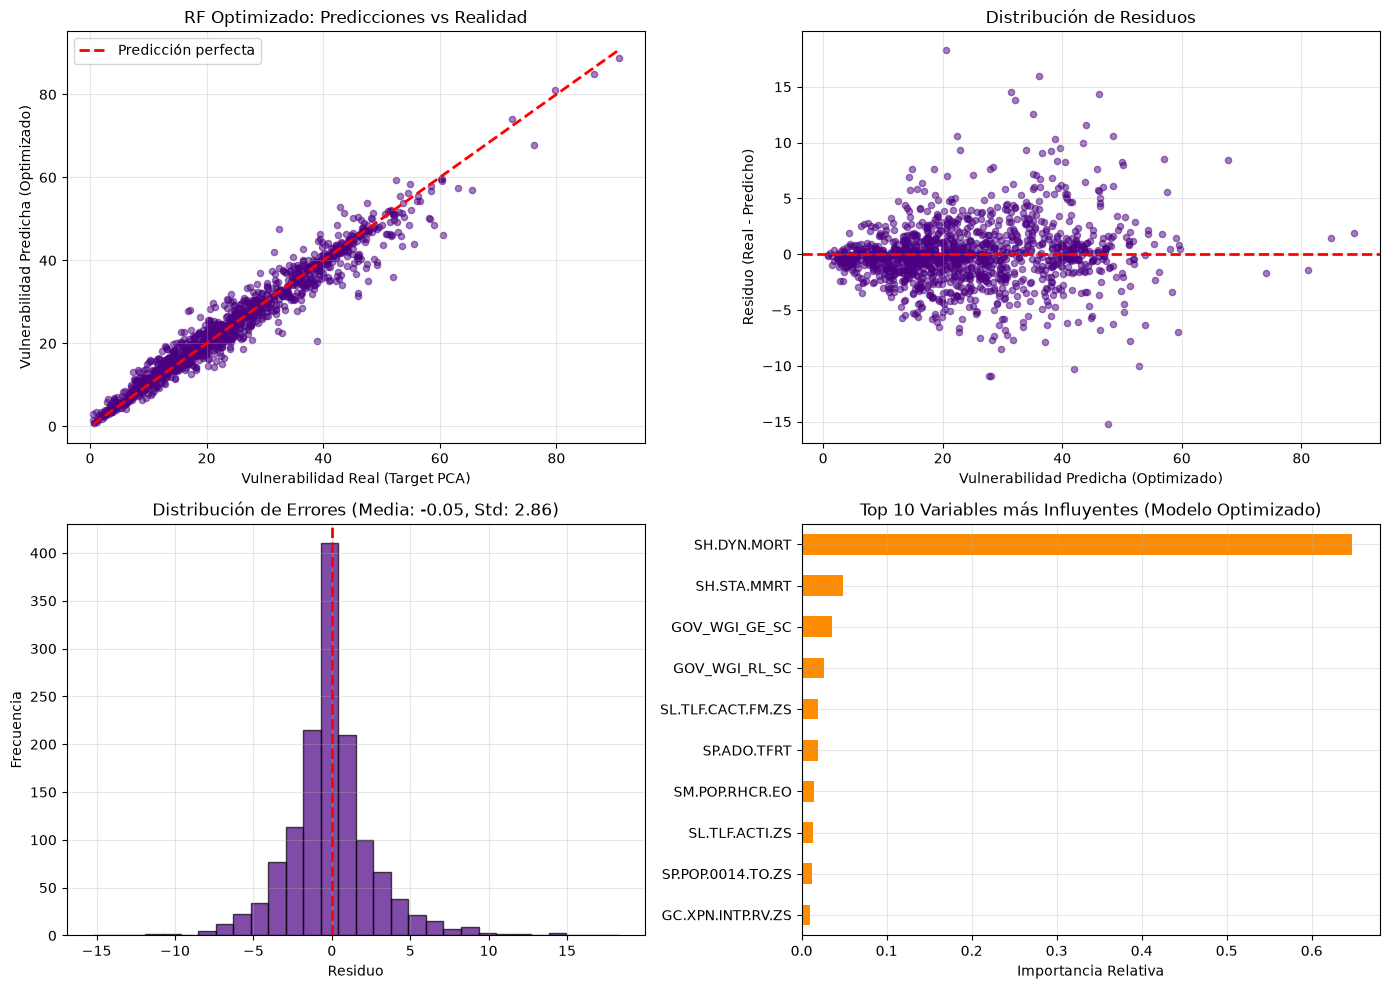

MÉTRICAS DE RENDIMIENTO - RANDOM FOREST OPTIMIZADO
Residuo promedio: -0.0459
Desv. estándar de residuos: 2.8629
R² Score: 0.9562
RMSE: 2.8633
Error Porcentual Absoluto Medio (MAPE): 10.52%


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============ VISUALIZACIÓN: RANDOM FOREST OPTIMIZADO ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 🟣 GRÁFICA 1 (arriba-izquierda): Predicciones vs Reales
ax1 = axes[0, 0]
ax1.scatter(y_test, pred_opt, alpha=0.5, s=20, color='indigo')
min_val = np.minimum(y_test.min(), pred_opt.min())
max_val = np.maximum(y_test.max(), pred_opt.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('Vulnerabilidad Real (Target PCA)')
ax1.set_ylabel('Vulnerabilidad Predicha (Optimizado)')
ax1.set_title('RF Optimizado: Predicciones vs Realidad')
ax1.legend()
ax1.grid(alpha=0.3)

# 🟣 GRÁFICA 2 (arriba-derecha): Distribución de Residuos
ax2 = axes[0, 1]
residuos_opt = y_test.to_numpy().flatten() - pred_opt.flatten()
ax2.scatter(pred_opt, residuos_opt, alpha=0.5, s=20, color='indigo')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Vulnerabilidad Predicha (Optimizado)')
ax2.set_ylabel('Residuo (Real - Predicho)')
ax2.set_title('Distribución de Residuos')
ax2.grid(alpha=0.3)

# 🟣 GRÁFICA 3 (abajo-izquierda): Histograma de Residuos
ax3 = axes[1, 0]
ax3.hist(residuos_opt, bins=30, edgecolor='black', alpha=0.7, color='indigo')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuo')
ax3.set_ylabel('Frecuencia')
ax3.set_title(f'Distribución de Errores (Media: {residuos_opt.mean():.2f}, Std: {residuos_opt.std():.2f})')
ax3.grid(alpha=0.3)

# 🟠 GRÁFICA 4 (abajo-derecha): Importancia de Variables (Feature Importance)
ax4 = axes[1, 1]
# Extraemos las importancias directamente del modelo optimizado
importancias_opt = pd.Series(modelo_optimizado.feature_importances_, index=X_train.columns)
importancias_opt.nlargest(10).sort_values().plot(kind='barh', ax=ax4, color='darkorange')
ax4.set_xlabel('Importancia Relativa')
ax4.set_title('Top 10 Variables más Influyentes (Modelo Optimizado)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ====================================================================
# IMPRESIÓN DE ESTADÍSTICAS FINALES
# ====================================================================
print("====================================================")
print("MÉTRICAS DE RENDIMIENTO - RANDOM FOREST OPTIMIZADO")
print("====================================================")
print(f'Residuo promedio: {residuos_opt.mean():.4f}')
print(f'Desv. estándar de residuos: {residuos_opt.std():.4f}')
print(f'R² Score: {r2_opt:.4f}')
print(f'RMSE: {rmse_opt:.4f}')
print(f'Error Porcentual Absoluto Medio (MAPE): {mape_opt:.2f}%')
print("====================================================")

## Pesos de las variables
1.  En primer lugar podemos ver como la mortalidad infantil supera un 60% del peso en el modelo lo cual tiene sentido si pensamos en que una sociedad que no es capaz de mantener con vida a los más pequeños difícilmente tiene una buena capacidad sanitaria y una falta de acceso a agua potable, alimentación ni infraestruturas básicas

2.  A esta le sigue el peso de la sanidad materna probablemente por las mismas razones que la mortalidad infantil

3.  Tras esta le siguen indicadores del nivel de calidad de la gobernanza

### Conclusión 
Por lo anteriormente visto podemos ver concluir que la estructura y vulnerabilidad de un pais  no depende probablemente tanto de valores financieros o de PIB a corto plazo como se suelen usar en diversos medios sino en otra clase de indices más estructurales los cuales afectan mayoritariamente a la población ya sea de una manera más directa como pueden ser la mortalidad infantil, mala calidad de las infraestruturas o más indirectas como lo competente que sea un gobierno.